# Trabajo Práctico N° 1 — Análisis Exploratorio de Datos
## Dataset: Hotel Bookings

**Autor:** Marcelo Vieira  
**Diplomatura en Inteligencia Artificial**

---

## Objetivo

Realizar un análisis exploratorio (EDA) sobre el dataset *Hotel Bookings*, que contiene reservas de dos hoteles (un hotel urbano y un resort) entre 2015 y 2017. El análisis busca limpiar los datos, comprender sus distribuciones, detectar valores atípicos y responder un conjunto de hipótesis seleccionadas por su **utilidad de negocio**.

## Hipótesis a investigar

Las hipótesis se eligieron priorizando su aplicabilidad a decisiones reales de gestión hotelera. Cada una habilita una acción concreta del negocio.

1. **H1.** El **canal de distribución** (`market_segment`) predice la cancelación: las reservas vía OTAs (`Online TA`) cancelan más que las directas o corporativas. → *Optimizar el mix de canales y la rentabilidad real.*
2. **H2.** A **más pedidos especiales** (`total_of_special_requests`), **menor probabilidad de cancelación**. → *Scoring de riesgo en el momento de la reserva.*
3. **H3.** Cuanto **mayor el `lead_time`** (días de anticipación), mayor la probabilidad de cancelación. → *Segmentar la cartera de reservas futuras y planificar overbooking.*
4. **H4.** Los **huéspedes repetidos** (`is_repeated_guest = 1`) cancelan menos que los nuevos. → *Justificar inversión en programas de fidelización.*
5. **H5.** El **`adr`** (precio medio diario) tiene un **patrón estacional marcado y difiere entre tipos de hotel**. → *Pricing dinámico y revenue management.*

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética para que todas las visualizaciones sean consistentes
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

## 2. Carga del dataset

El dataset original contiene 119.390 reservas y 32 columnas. Cumple holgadamente con el requisito mínimo del TP (50.000 filas y 10 columnas) y combina variables numéricas, categóricas y temporales.

In [2]:
df = pd.read_csv('../hotel_bookings.csv')
print(f'Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
df.head()

Filas: 119,390  |  Columnas: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Resumen rápido de tipos
df.dtypes.value_counts()

int64      16
str        12
float64     4
Name: count, dtype: int64

In [4]:
# Estadísticos generales de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


## 3. Limpieza de datos

En esta sección revisamos integridad: nulos, duplicados, inconsistencias y tipos. Documentamos cada decisión para poder defenderla.

### 3.1 Valores nulos

In [5]:
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
nulos_df = pd.DataFrame({'nulos': nulos, 'porcentaje (%)': (nulos / len(df) * 100).round(2)})
nulos_df

,nulos,porcentaje (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


**Decisiones de imputación:**

- `children` (4 nulos, < 0,01 %): imputamos con 0 porque son casos aislados y la mediana también es 0.
- `country` (488 nulos, 0,4 %): imputamos con `'Unknown'` para preservar las filas sin asumir un país.
- `agent` (16.340 nulos, 13,7 %): un nulo aquí significa que la reserva no se hizo a través de un agente. Reemplazamos por 0 (sin agente).
- `company` (112.593 nulos, 94,3 %): la mayoría de las reservas son de personas físicas, no de empresas. Reemplazamos por 0 (sin empresa).

In [6]:
df['children'] = df['children'].fillna(0).astype(int)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0).astype(int)
df['company'] = df['company'].fillna(0).astype(int)

# Verificación
df.isnull().sum().sum()

np.int64(0)

### 3.2 Duplicados

El dataset contiene filas duplicadas (no incluye un ID único de reserva). Para no inflar artificialmente las métricas las eliminamos.

In [7]:
duplicados = df.duplicated().sum()
print(f'Duplicados exactos: {duplicados:,}  ({duplicados / len(df) * 100:.2f} %)')
df = df.drop_duplicates().reset_index(drop=True)
print(f'Filas tras eliminar duplicados: {len(df):,}')

Duplicados exactos: 31,994  (26.80 %)
Filas tras eliminar duplicados: 87,396


### 3.3 Inconsistencias

Detectamos dos inconsistencias claras:

1. **Reservas sin huéspedes:** filas donde `adults + children + babies == 0`. No tienen sentido de negocio, las descartamos.
2. **`adr` (precio medio diario):** hay valores negativos y al menos un valor extremo (>5000). Los eliminamos como outliers no válidos.

In [8]:
# Reservas fantasma
huespedes = df['adults'] + df['children'] + df['babies']
print(f'Reservas con 0 huéspedes: {(huespedes == 0).sum()}')
df = df[huespedes > 0].reset_index(drop=True)

# adr inválidos
print(f'adr negativos: {(df["adr"] < 0).sum()}')
print(f'adr > 1000  : {(df["adr"] > 1000).sum()}')
df = df[(df['adr'] >= 0) & (df['adr'] <= 1000)].reset_index(drop=True)

print(f'Filas finales: {len(df):,}')

Reservas con 0 huéspedes: 166
adr negativos: 1
adr > 1000  : 1
Filas finales: 87,228


### 3.4 Construcción de columnas auxiliares

- **`arrival_date`**: combinamos año, mes y día en una sola fecha para análisis temporales.
- **`total_nights`**: suma de noches de fin de semana y de semana.
- **`total_guests`**: total de huéspedes por reserva.
- **`arrival_month_num`**: orden numérico del mes (para gráficos ordenados).

In [9]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d'
)
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']

meses_orden = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=meses_orden, ordered=True)
df['arrival_month_num'] = df['arrival_date_month'].cat.codes + 1

df[['arrival_date', 'total_nights', 'total_guests']].head()

,arrival_date,total_nights,total_guests
0,2015-07-01,0,2
1,2015-07-01,0,2
2,2015-07-01,1,1
3,2015-07-01,1,1
4,2015-07-01,2,2


## 4. Análisis exploratorio (EDA)

### 4.1 Tipos de variables y resumen general

In [10]:
tipos = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'unicos': df.nunique(),
    'ejemplo': df.iloc[0]
})
tipos.head(15)

,tipo,unicos,ejemplo
hotel,str,2,Resort Hotel
is_canceled,int64,2,0
lead_time,int64,479,342
arrival_date_year,int64,3,2015
arrival_date_month,category,12,July
arrival_date_week_number,int64,53,27
arrival_date_day_of_month,int64,31,1
stays_in_weekend_nights,int64,17,0
stays_in_week_nights,int64,33,0
adults,int64,14,2


In [11]:
# Tasa global de cancelación: nuestra variable target natural
tasa_cancel = df['is_canceled'].mean() * 100
print(f'Tasa global de cancelación: {tasa_cancel:.2f} %')

Tasa global de cancelación: 27.52 %


### 4.2 Histogramas con KDE (3)

Distribuciones de las tres variables numéricas más relevantes para nuestras hipótesis.

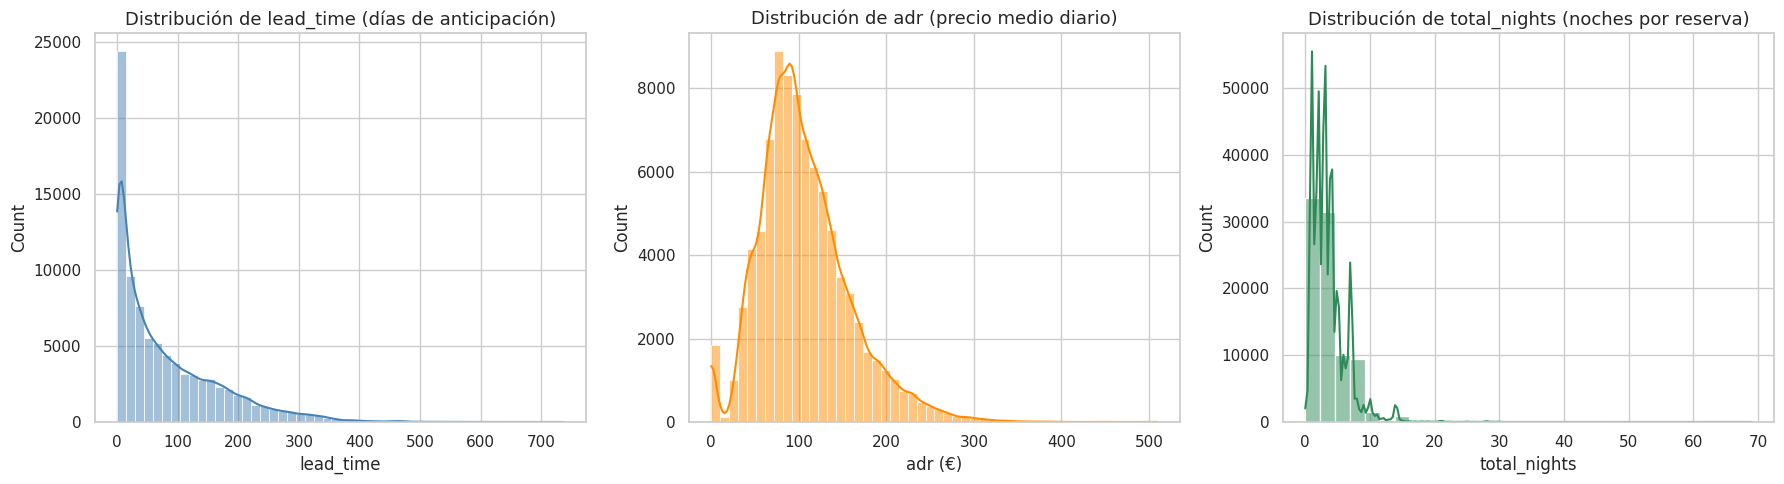

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['lead_time'], kde=True, bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de lead_time (días de anticipación)')
axes[0].set_xlabel('lead_time')

sns.histplot(df['adr'], kde=True, bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('Distribución de adr (precio medio diario)')
axes[1].set_xlabel('adr (€)')

sns.histplot(df['total_nights'], kde=True, bins=30, ax=axes[2], color='seagreen')
axes[2].set_title('Distribución de total_nights (noches por reserva)')
axes[2].set_xlabel('total_nights')

plt.tight_layout()
plt.show()

**Lectura:**
- `lead_time` está fuertemente sesgada a la derecha: la mayoría reserva con poca anticipación, pero hay una cola larga de reservas hechas con meses de antelación.
- `adr` se concentra entre 50 y 150 €, con cola derecha (estancias premium).
- `total_nights` muestra una preferencia por estadías cortas (1 a 4 noches).

### 4.3 Boxplots (3) — detección de outliers

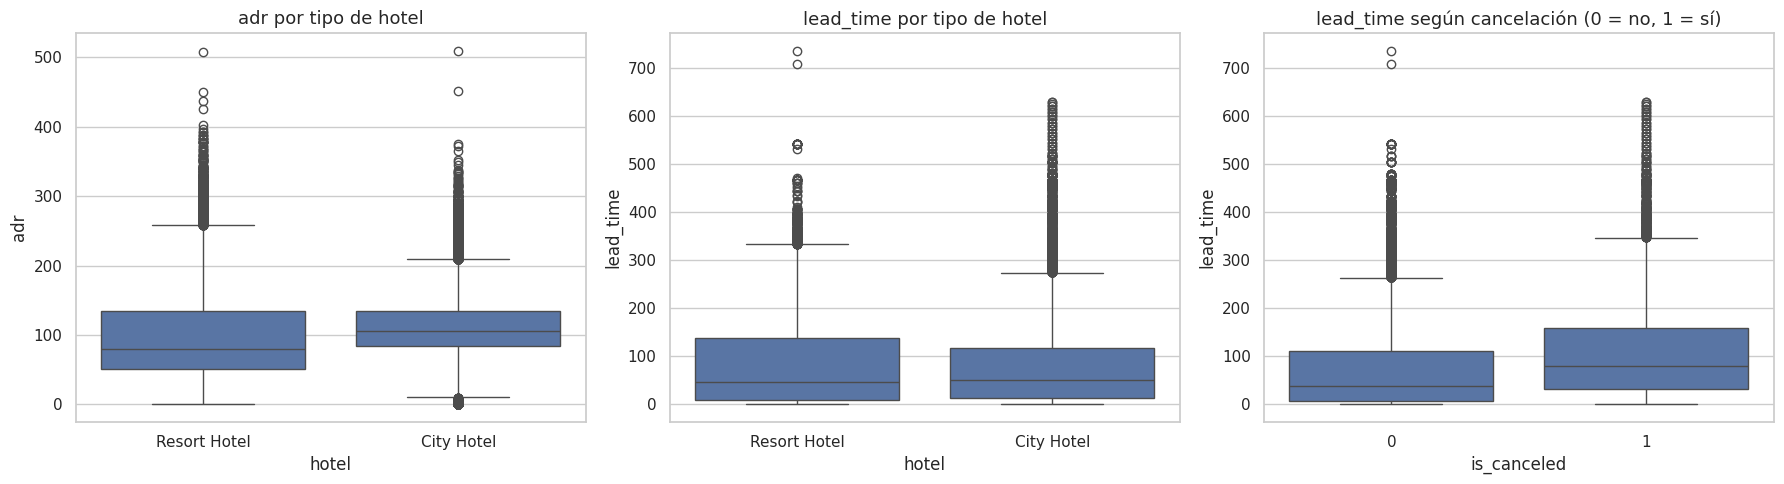

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='hotel', y='adr', data=df, ax=axes[0])
axes[0].set_title('adr por tipo de hotel')

sns.boxplot(x='hotel', y='lead_time', data=df, ax=axes[1])
axes[1].set_title('lead_time por tipo de hotel')

sns.boxplot(x='is_canceled', y='lead_time', data=df, ax=axes[2])
axes[2].set_title('lead_time según cancelación (0 = no, 1 = sí)')

plt.tight_layout()
plt.show()

**Lectura:**
- Hay outliers de `adr` en ambos hoteles, pero el rango intercuartil del *City Hotel* es algo más alto.
- En el boxplot 3 vemos a simple vista que la mediana de `lead_time` para reservas canceladas es claramente mayor que para no canceladas: primer indicio a favor de **H1**.

### 4.4 Scatterplots (2) — relaciones entre variables

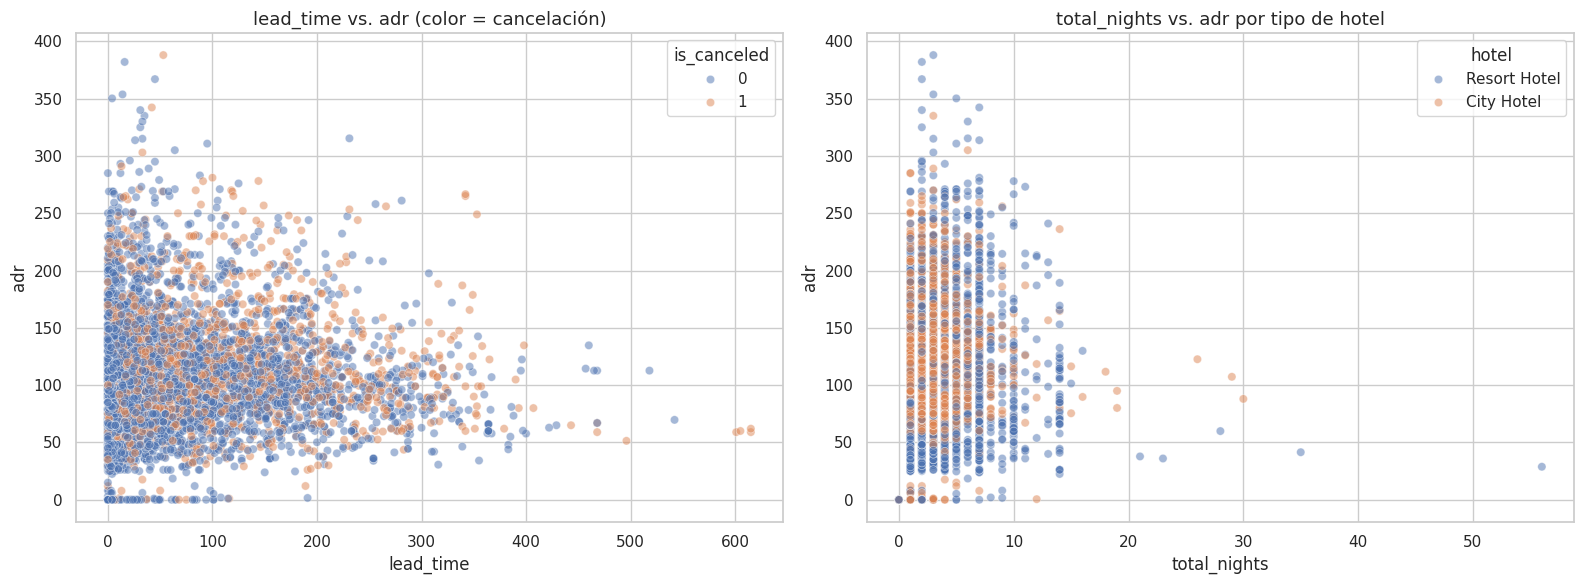

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Para no saturar, sampleamos 5000 puntos
muestra = df.sample(5000, random_state=42)

sns.scatterplot(data=muestra, x='lead_time', y='adr', hue='is_canceled',
                alpha=0.5, ax=axes[0])
axes[0].set_title('lead_time vs. adr (color = cancelación)')

sns.scatterplot(data=muestra, x='total_nights', y='adr', hue='hotel',
                alpha=0.5, ax=axes[1])
axes[1].set_title('total_nights vs. adr por tipo de hotel')

plt.tight_layout()
plt.show()

### 4.5 Matriz de correlación

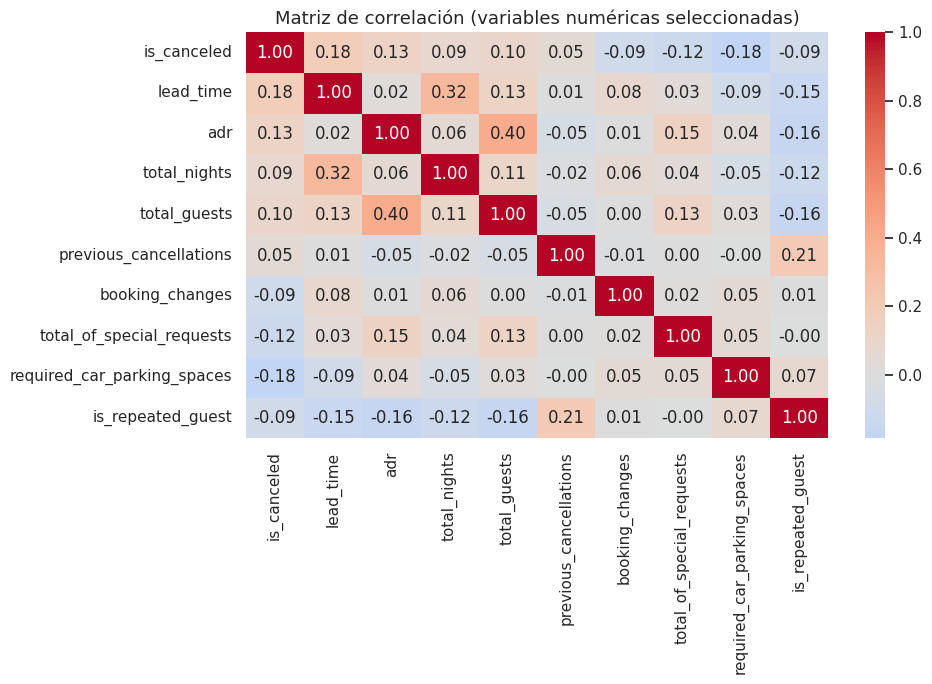

In [15]:
num_cols = ['is_canceled', 'lead_time', 'adr', 'total_nights', 'total_guests',
            'previous_cancellations', 'booking_changes',
            'total_of_special_requests', 'required_car_parking_spaces',
            'is_repeated_guest']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación (variables numéricas seleccionadas)')
plt.tight_layout()
plt.show()

**Lectura:** Las correlaciones más interesantes con `is_canceled` son:
- `lead_time` positiva (refuerza H1)
- `total_of_special_requests` negativa (refuerza H5)
- `required_car_parking_spaces` negativa
- `previous_cancellations` positiva

## 5. Verificación de hipótesis

### H1. ¿El canal de distribución (`market_segment`) predice la cancelación?

Comparamos la tasa de cancelación entre los distintos segmentos de mercado, ordenados de mayor a menor.

                reservas  tasa_cancel
market_segment                       
Undefined              2       100.00
Online TA          51553        35.38
Groups              4921        27.07
Aviation             226        19.91
Offline TA/TO      13854        14.84
Direct             11780        14.75
Complementary        692        12.28
Corporate           4200        12.12


/tmp/ipykernel_717181/4043355643.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=seg.index, y=seg['tasa_cancel'], palette='Reds_r')


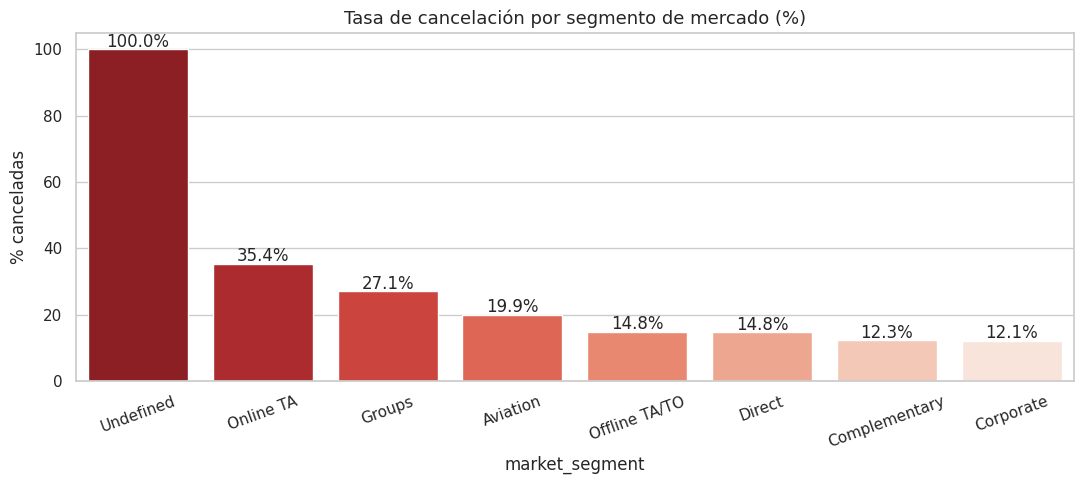

In [16]:
# Tasa de cancelación y volumen de reservas por segmento
seg = df.groupby('market_segment').agg(
    reservas=('is_canceled', 'size'),
    tasa_cancel=('is_canceled', 'mean')
).sort_values('tasa_cancel', ascending=False)
seg['tasa_cancel'] = (seg['tasa_cancel'] * 100).round(2)
print(seg)

# Visualización: barras con tasa de cancelación por canal
plt.figure(figsize=(11, 5))
ax = sns.barplot(x=seg.index, y=seg['tasa_cancel'], palette='Reds_r')
plt.title('Tasa de cancelación por segmento de mercado (%)')
plt.xlabel('market_segment')
plt.ylabel('% canceladas')
plt.xticks(rotation=20)
for i, v in enumerate(seg['tasa_cancel'].values):
    ax.text(i, v + 0.7, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

### H2. ¿A más pedidos especiales, menos cancelación?

La cantidad de pedidos especiales (`total_of_special_requests`) es una **proxy del nivel de compromiso del cliente**: alguien que se toma el trabajo de pedir cuna, vista o un tipo de cama en general no va a cancelar. Disponible al momento de la reserva, ideal para *scoring*.

total_of_special_requests
0    33.25
1    22.44
2    21.32
3    17.11
4    10.62
5     5.56
Name: is_canceled, dtype: float64


/tmp/ipykernel_717181/703212292.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tasa_pedidos.index, y=tasa_pedidos.values, palette='viridis')


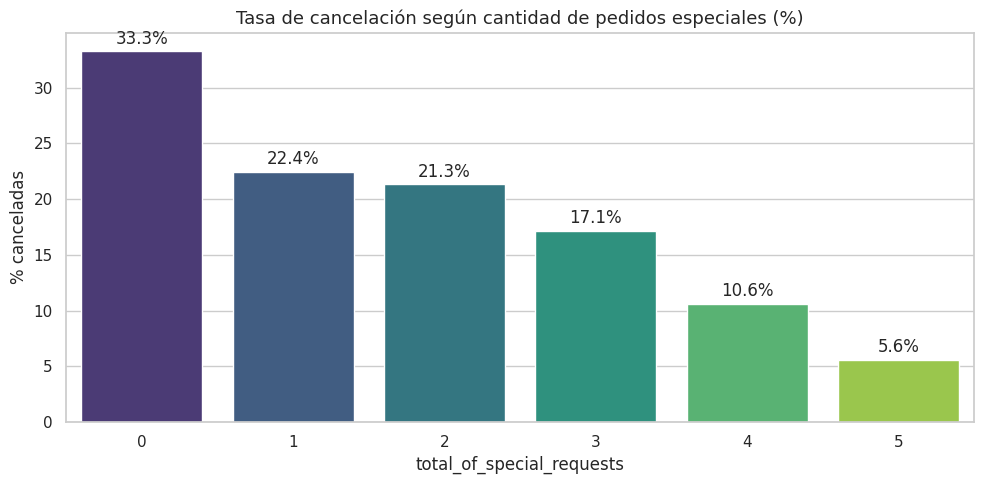

In [17]:
tasa_pedidos = df.groupby('total_of_special_requests')['is_canceled'].mean() * 100
print(tasa_pedidos.round(2))

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=tasa_pedidos.index, y=tasa_pedidos.values, palette='viridis')
plt.title('Tasa de cancelación según cantidad de pedidos especiales (%)')
plt.xlabel('total_of_special_requests')
plt.ylabel('% canceladas')
for i, v in enumerate(tasa_pedidos.values):
    ax.text(i, v + 0.7, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

### H3. ¿A mayor `lead_time`, mayor cancelación?

Discretizamos `lead_time` en rangos y comparamos la tasa de cancelación de cada uno.

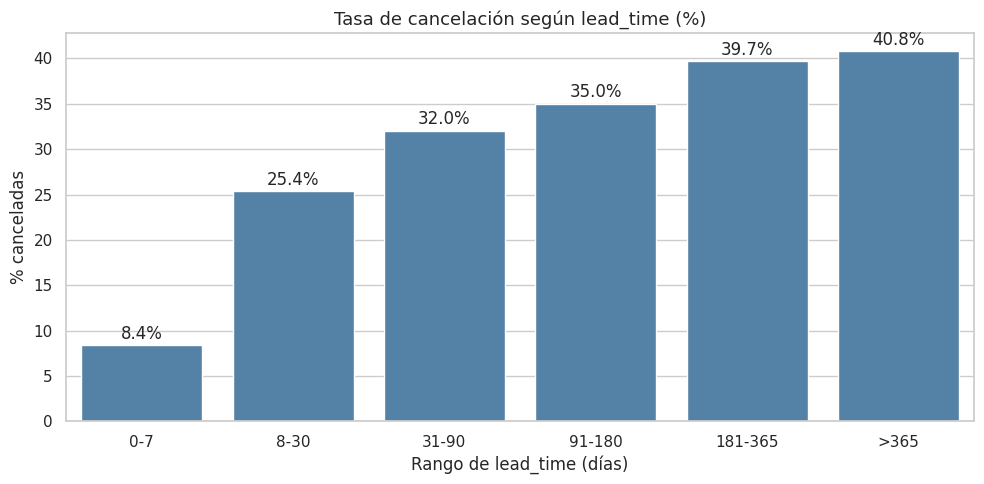

In [18]:
# Agrupamos lead_time en rangos y calculamos la tasa de cancelación de cada uno
df['lead_time_bin'] = pd.cut(df['lead_time'],
                              bins=[-1, 7, 30, 90, 180, 365, 800],
                              labels=['0-7','8-30','31-90','91-180','181-365','>365'])
tasa_por_bin = df.groupby('lead_time_bin', observed=True)['is_canceled'].mean() * 100

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=tasa_por_bin.index, y=tasa_por_bin.values, color='steelblue')
plt.title('Tasa de cancelación según lead_time (%)')
plt.xlabel('Rango de lead_time (días)')
plt.ylabel('% canceladas')
for i, v in enumerate(tasa_por_bin.values):
    ax.text(i, v + 0.7, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

### H4. ¿Los huéspedes repetidos cancelan menos?

Comparamos la tasa de cancelación entre clientes que ya se hospedaron antes y clientes nuevos. Adicionalmente, mostramos la proporción de cada grupo en el dataset (gráfico de torta).

No repetido    28.32
Repetido        7.73
Name: is_canceled, dtype: float64


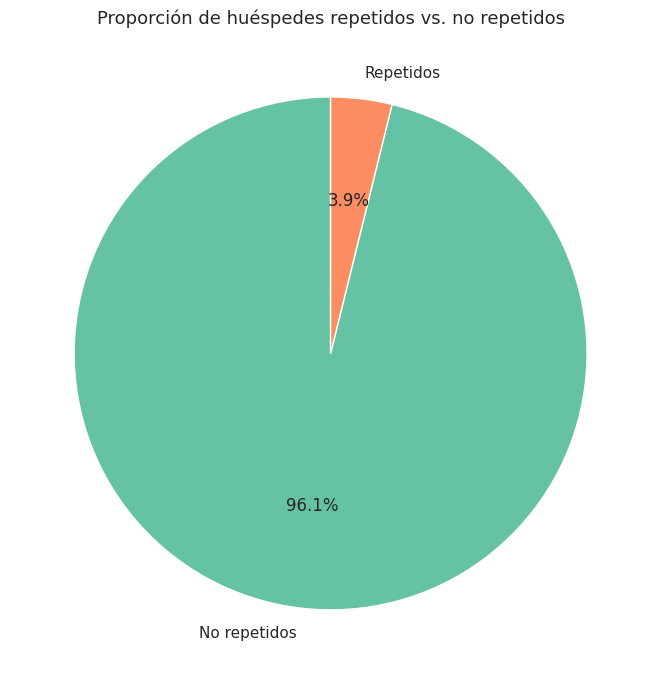

In [19]:
tasa_repetidos = df.groupby('is_repeated_guest')['is_canceled'].mean() * 100
tasa_repetidos.index = ['No repetido', 'Repetido']
print(tasa_repetidos.round(2))

# Visualización adicional 3: gráfico de torta
conteos = df['is_repeated_guest'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(conteos.values,
        labels=['No repetidos', 'Repetidos'],
        autopct='%1.1f%%',
        colors=['#66c2a5', '#fc8d62'],
        startangle=90)
plt.title('Proporción de huéspedes repetidos vs. no repetidos')
plt.tight_layout()
plt.show()

### H5. ¿El `adr` tiene patrón estacional y difiere por hotel?

Calculamos el precio medio diario (`adr`) por mes para cada tipo de hotel y lo graficamos como serie temporal.

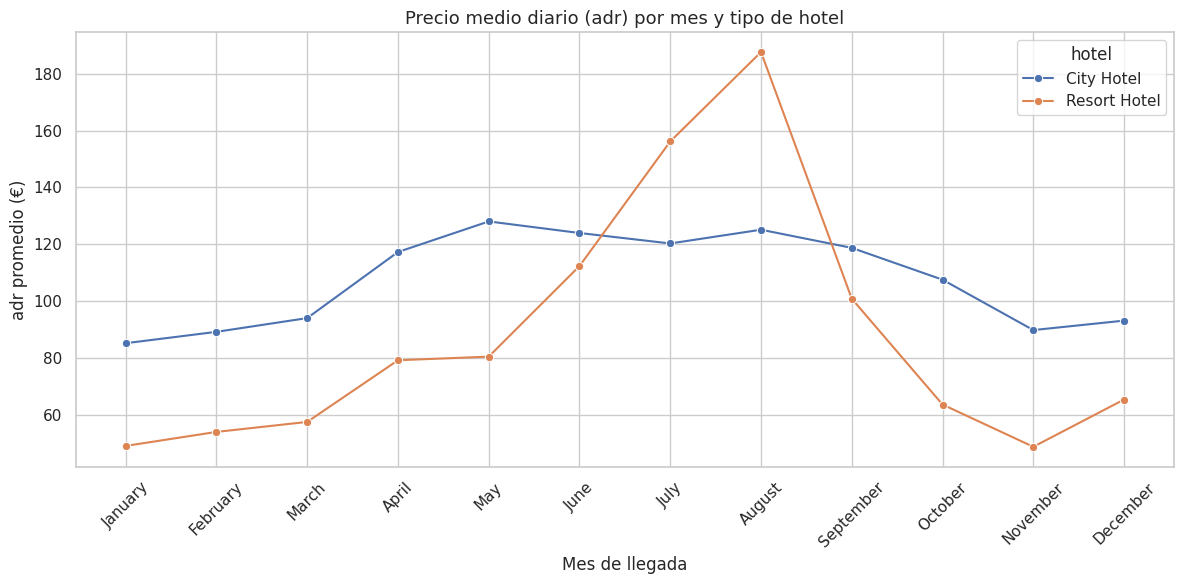

In [20]:
adr_mensual = df.groupby(['arrival_date_month', 'hotel'], observed=True)['adr'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=adr_mensual, x='arrival_date_month', y='adr', hue='hotel', marker='o')
plt.title('Precio medio diario (adr) por mes y tipo de hotel')
plt.xlabel('Mes de llegada')
plt.ylabel('adr promedio (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Conclusiones

El análisis exploratorio sobre 119.390 reservas (87.228 tras limpieza) permite responder las hipótesis y derivar acciones concretas de negocio. La tasa global de cancelación es del **27,5 %**.

- **H1 — Confirmada.** El segmento `Online TA` tiene la tasa de cancelación más alta entre los canales con volumen relevante: **35,4 %**, contra **14,8 %** de `Direct`, **14,8 %** de `Offline TA/TO` y **12,1 %** de `Corporate`. Es decir, las OTAs cancelan **más del doble** que el canal directo o el corporativo. **Acción:** revisar el mix de canales y la fórmula de margen — la rentabilidad real por reserva cambia drásticamente al incorporar el churn al cálculo, no solo la comisión nominal.

- **H2 — Confirmada.** A más pedidos especiales, menor cancelación: pasa de **33,3 %** con 0 pedidos a **5,6 %** con 5 pedidos, en una caída monótona y muy marcada. Es una señal de compromiso disponible al momento de la reserva. **Acción:** *scoring* en tiempo real — disparar acciones diferenciadas (recordatorios, ofertas, llamadas) sobre las reservas sin pedidos especiales.

- **H3 — Confirmada.** Las reservas con `lead_time` corto (0-7 días) cancelan apenas **8,4 %**, mientras que las hechas con más de un año superan el **40 %**. La relación es monótona creciente. **Acción:** segmentar la cartera de reservas futuras por nivel de riesgo y planificar overbooking con un % de cancelación esperado por bin.

- **H4 — Confirmada.** Los huéspedes repetidos cancelan solo el **7,7 %**, frente al **28,3 %** de los nuevos — ~20 puntos porcentuales menos. Aunque solo representan el **3,9 %** del total de reservas, son sustancialmente más confiables. **Acción:** justificar inversión en programas de fidelización con métrica clara de retención esperada.

- **H5 — Confirmada.** El `adr` muestra estacionalidad fuerte y opuesta entre hoteles. El *Resort Hotel* va de **€49 (noviembre)** a **€188 (agosto)** — pico de verano, casi cuadruplica su tarifa. El *City Hotel* es mucho más estable: de **€85 (enero)** a **€128 (mayo)**, con picos suaves en primavera y otoño. En julio-agosto el Resort supera al City, lo que invierte la jerarquía habitual. **Acción:** capitalizar la temporada alta del Resort con tarifas agresivas y diseñar paquetes corporativos / fin de semana para los meses flojos del City.

### Hallazgos relevantes

1. **Predictores fuertes de cancelación detectados:** segmento `Online TA`, ausencia de pedidos especiales, `lead_time` alto y cliente nuevo. Combinados forman un modelo simple y accionable de *risk scoring* — un cliente nuevo, vía OTA, con lead_time alto y sin pedidos especiales tiene una probabilidad de cancelación que supera ampliamente la media del 27,5 %.
2. **Calidad de datos:** el dataset traía 26,8 % de duplicados y 94 % de nulos en `company`. Cualquier KPI calculado sobre los datos crudos habría estado sesgado — la limpieza fue tan importante como el análisis.
3. **Foco operativo:** la mayor oportunidad está en el *City Hotel*, que combina mayor volumen, fuerte exposición a OTAs y cancelaciones materiales. Allí el ROI de un programa de retención sería más alto.

---